In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
regression_who_results = pd.read_csv("/home/sak0914/who-analysis/results/Regression_Final_June2024_Tier1.csv")

coll_2014 = pd.read_csv("./data_processing/data_utils/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETH",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

    if regression:
        model_type = 'Reg'
    else:
        model_type = 'CNN'
    
    results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
    results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

    return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    # return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]


def differences_significant_CNN_Reg(df, model, variable, direction='two-sided'):

    results_1 = df.query("Model=='CNN' & Addl_Data==@model")[variable].values
    results_2 = df.query("Model=='Reg' & Addl_Data==@model")[variable].values

    return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    # return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

cryptic_wgs_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")
df_cryptic = pd.read_csv("MIC_data/CRyPTIC_reuse_table_20231208.csv")
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETH': 5, 'MXF': 0.5, 'LEV': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}

isolate_variants = pd.read_csv(os.path.join(os.path.dirname(data_dir), "isolate_WHO_catalog_variants.csv")).dropna(subset='variant').reset_index(drop=True)

/tmp/ipykernel_30790/3881435069.py:8: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


In [ ]:
# for drug in os.listdir(data_dir):
#     models_lst = [f"/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/{drug}{val}" for val in ['', '_lineage', '_lineage_amino_acid', '_amino_acid']]
    
#     bootstrap_to_run = []
#     permutation_to_run = []
#     primary_to_run = []
    
#     for model_path in models_lst:
    
#         if not os.path.isfile(f"{model_path}/results.csv"):
#             primary_to_run.append(model_path)
            
#         if os.path.isdir(f"{model_path}/bootstrapping"):
#             if len(os.listdir(f"{model_path}/bootstrapping")) < 10:
#                 bootstrap_to_run.append(model_path)
#         else:
#             bootstrap_to_run.append(model_path)
    
#         if os.path.isdir(f"{model_path}/saliency/permutation_test"):
#             if len(os.listdir(f"{model_path}/saliency/permutation_test")) < 10:
#                 permutation_to_run.append(model_path)
#         else:
#             permutation_to_run.append(model_path)

#     print(primary_to_run)
#     print(bootstrap_to_run)

# Do AA Properties Cause a General Increase in Predicted MICs, suggesting simple overfitting to protein disruption?

In [8]:
AA_pred_change_dict = {}

for drug in os.listdir(data_dir):
    
    try:
        if drug in ['MXF', 'BDQ', 'ETH']:
            model_path = f"{drug}_lineage"
        else:
            model_path = drug
    
        df_pred = pd.read_csv(os.path.join(results_dir, model_path, "test_predictions.csv"))
        df_pred_AA = pd.read_csv(os.path.join(results_dir, f"{model_path}_amino_acid", "test_predictions.csv"))
        
        df_combined = df_pred[['Isolate', 'y_pred', 'lower', 'upper', 'y_test']].merge(df_pred_AA[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_pred_AA'}), on='Isolate')
        df_combined['y_pred_exp'] = np.exp2(df_combined['y_pred'])
        df_combined['y_pred_AA_exp'] = np.exp2(df_combined['y_pred_AA'])
        
        # df_combined['pred_diff'] = df_combined['y_pred_AA_exp'] - df_combined['y_pred_exp']
        df_combined['fold_change'] = df_combined['y_pred_AA_exp'] / df_combined['y_pred_exp']

        AA_pred_change_dict[drug] = df_combined['fold_change'].mean()
        # AA_pred_change_dict[drug] = df_combined['pred_diff'].mean()
            
    except:
        print(f"{drug} not finished")

DLM not finished
LZD not finished


In [9]:
np.array(list(AA_pred_change_dict.values())).min(), np.array(list(AA_pred_change_dict.values())).max()

(0.9291766348135486, 1.5744763141545737)

# Quantitative Model Comparison

In [2]:
def get_all_single_drug_models(drug, regression=False):
    '''
    This function gets all the models for a given drug that have model results
    '''

    # gets all directories with the drug name
    CNN_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/results.csv"))
    
    # if regression or bootstrap, then all directories must also have those corresponding directories. The regression script performs bootstrapping, so don't need to check them separately
    if regression:
        regression_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/ridge/results.csv"))
    else:
        regression_fNames = []
        
    df_combined = []
    
    for fName in CNN_fNames + regression_fNames:
        
        df = pd.read_csv(fName)
        
        model_name = '- Lineage'
    
        num_addl_features = 0
    
        if 'lineage' in fName:
            # model_name += '\n+Lineage'
            model_name = '+ Lineage'
            num_addl_features += 1
    
        # if 'peptide' in fName:
        #     model_name += '\n+Peptide Lengths'
        #     num_addl_features += 1
    
        # if 'amino_acid' in fName:
        #     model_name += '\n+AA Properties'
        #     num_addl_features += 1
    
        if 'tier2' in fName:
            model_name += '\n+ Tier 2 Loci'
            num_addl_features += 1
        
        # # remove the nucleotide descriptor for non-base models
        # if num_addl_features != 0:
        #     model_name = model_name.replace('Nucleotide', '')
    
        # remove leading newline characters
        model_name = model_name.lstrip()
            
        df['Addl_Data'] = model_name
            
        df_combined.append(df)

    df_combined = pd.concat(df_combined)

    # check no duplicate row identifiers
    assert len(df_combined[['Model', 'Addl_Data', 'CV']].drop_duplicates()) == len(df_combined)

    # exponentiate errors
    for col in ['Binned_MAE', 'Binned_MSE']:
        df_combined[f'{col}_exp'] = np.exp2(df_combined[col])

    # add
    df_combined['Without_doubling'] = 1 - df_combined['Within_doubling']

    # remove peptide lengths if present
    return df_combined.query("~Addl_Data.str.contains('Peptide')")

In [3]:
def plot_single_drug_model_comparison(drug, df_combined, plot_col='Binned_MAE_exp', model_order=None, mean_bar_offset=0.2, mean_bar_width=0.1, y_min=None, y_max=None, ylabel='', title='', saveName=None):

    color_palette = dict(zip(["CNN", "Reg", "Catalog"], sns.color_palette("Set2").as_hex()))

    if model_order is None:
        model_order = ['- Lineage', '+ Lineage'] #, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")

    # convert to percentages
    if 'doubling' in plot_col:
        df_combined[plot_col] *= 100

    fig_width = 1.2 * df_combined.Addl_Data.nunique()
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))
    
    sns.stripplot(data=df_combined,
                  x='Addl_Data',
                  order=model_order,
                  y=plot_col,
                  hue='Model',
                  hue_order=['Reg', 'CNN'],
                  palette=color_palette,
                  dodge=True,
                  jitter=True,
                  edgecolor='black',
                  linewidth=0.75,
                  size=5,
                  alpha=0.8,
                  zorder=1,
                  ax=ax
                  #log_scale=2
                 )
    
    for i, model_name in enumerate(model_order):
        for k, model_type in enumerate(['Reg', 'CNN']):
            
            median_error = df_combined.query(f"Model==@model_type & Addl_Data==@model_name")[plot_col].median()
    
            if k == 0:
                xpos = ax.get_xticks()[i] - mean_bar_offset
            else:
                xpos = ax.get_xticks()[i] + mean_bar_offset
                
            ax.hlines(y=median_error, xmin=xpos-mean_bar_width, xmax=xpos+mean_bar_width, color=color_palette[model_type], zorder=0)

    ref_font_size = 8
    
    plt.xlabel('', fontsize=ref_font_size)
    plt.ylabel(ylabel, fontsize=ref_font_size)
    plt.title(f'{abbr_drug_dict[drug]}', fontsize=ref_font_size)
    
    plt.xticks(fontsize=ref_font_size-1.5)
    plt.yticks(fontsize=ref_font_size-1)
    #plt.legend(title='', fontsize=ref_font_size-1, loc='best')
    try:
        ax.get_legend().remove()
    except:
        pass

    if y_max is None:
        y_max = df_combined[plot_col].max()*1.05
    
    plt.ylim(bottom=y_min, top=y_max)
    sns.despine()
    plt.tight_layout()

    if saveName is None:
        plt.show()
    else:
    
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
        
        plt.savefig(saveName, format='svg', bbox_inches='tight')

In [4]:
def get_performance_comparison_CNN_Reg(drug, model_order=None, plot_col='Binned_MAE', plot=True):
    
    df_combined = get_all_single_drug_models(drug, regression=True)

    color_palette = dict(zip(["CNN", "Reg", "Catalog"], sns.color_palette("Set2").as_hex()))

    if model_order is None:
        model_order = ['- Lineage', '+ Lineage', '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci'] #['+AA Properties', '+Lineage\n+AA Properties']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")
    
    if 'exp' in plot_col.lower():
        plot_y_min = 1
        title = 'Mean Absolute Error (Doublings)'
        ylabel = 'Relative Error'
        save_name = 'MAE_exp'
    elif 'doubling' in plot_col.lower():
        plot_y_min = 0
        title = 'Essential Disagreement'
        ylabel = 'Essential Disagreement'
        save_name = 'EA'
    else:
        plot_y_min = 0
        title = 'Mean Absolute Error'
        ylabel = 'Mean Absolute Error (log2-MIC)'
        save_name = 'MAE'

    if plot:
        plot_single_drug_model_comparison(drug, df_combined, plot_col=plot_col, model_order=model_order, mean_bar_width=0.15, y_min=plot_y_min, ylabel=ylabel, title=title, saveName=f"results/{abbr_drug_dict[drug]}/{save_name}.svg")
        
        # plot_single_drug_model_comparison(drug, df_combined, plot_col='Without_doubling', model_order=model_order, mean_bar_width=0.15, y_min=0, ylabel='Essential Disagreement (%)', title='Percent of Predictions >1 Doubling Away', saveName=f"results/{abbr_drug_dict[drug]}/EA.svg")
            
    df_pvals = pd.DataFrame(columns=['Model', 'Variable', 'CNN_better_pval', 'Reg_better_pval'])
    i = 0

    for model in df_combined.Addl_Data.unique():
        df_pvals.loc[i, :] = [model.replace('\n', ','), 
                              plot_col, 
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='less'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='greater')
                             ]
        i += 1
        
        # df_pvals.loc[i, :] = [model.replace('\n', ','), 
        #                       'Without_doubling',
        #                       differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='less'),
        #                       differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='greater')
        #                      ]
        # i += 1

    # # perform FDR correction at the single-drug level
    # _, cnn_better_bh_pvals, _, _ = sm.multipletests(df_pvals['CNN_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_CNN_better_pval'] = cnn_better_bh_pvals
    
    # _, reg_better_bh_pvals, _, _ = sm.multipletests(df_pvals['Reg_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_Reg_better_pval'] = reg_better_bh_pvals
    
    df_pvals['Drug'] = drug
    
    return df_combined, df_pvals



def get_performance_comparison_lineage(drug, regression=False):
    
    df_combined = get_all_single_drug_models(drug, regression=True)

    if regression:
        df_combined = df_combined.query("Model=='Reg'")
    else:
        df_combined = df_combined.query("Model=='CNN'")


    df_pvals = pd.DataFrame(columns=['Variable', 'Lineage_Better_pval', 'Lineage_Worse_pval'])
    i = 0

    for variable in ['Binned_MAE']:
        
        df_pvals.loc[i, :] = [variable,        
                              differences_significant_two_models(df_combined, '+ Lineage', '- Lineage', variable, regression=regression, direction='less'),
                              differences_significant_two_models(df_combined, '+ Lineage', '- Lineage', variable, regression=regression, direction='greater')
                             ]
        i += 1
            
    df_pvals['Drug'] = drug
    return df_pvals

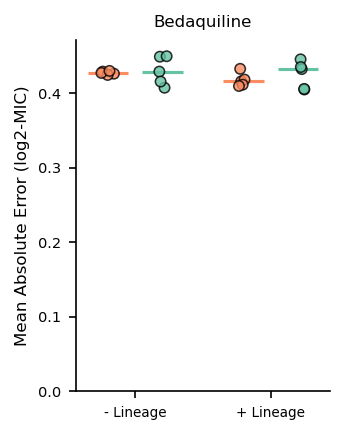

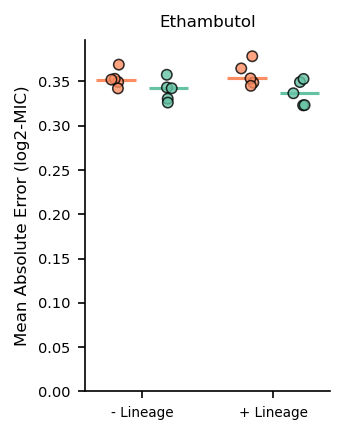

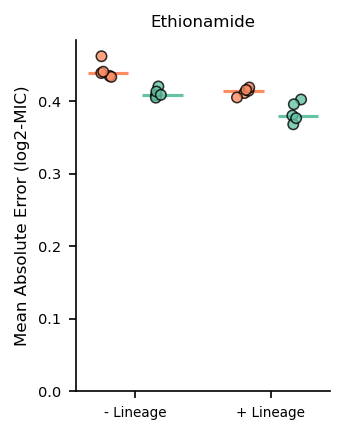

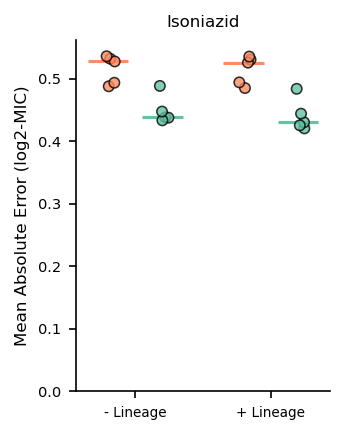

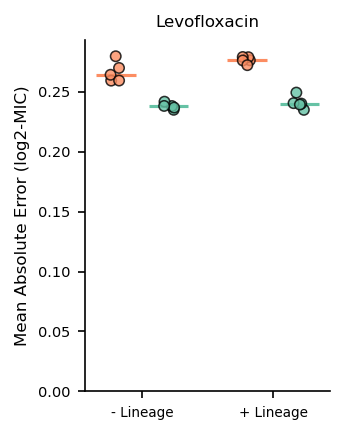

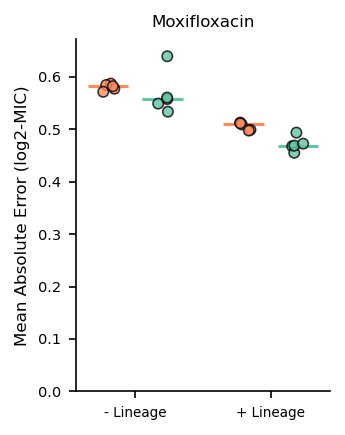

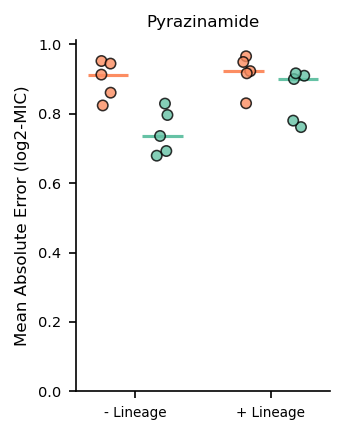

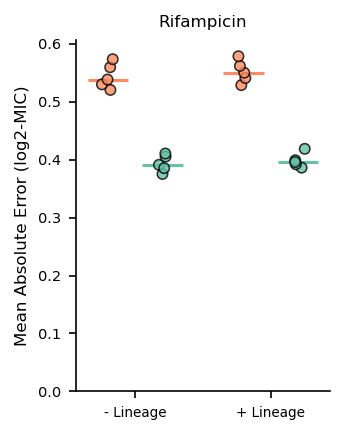

In [6]:
df_results_combined = []
df_pvals_combined = []

for drug in os.listdir(data_dir):
    try:
        df_results, df_pvals = get_performance_comparison_CNN_Reg(drug, model_order=['- Lineage', '+ Lineage'], plot_col='Binned_MAE', plot=True)
        df_results_combined.append(df_results)
        df_pvals_combined.append(df_pvals)
    except:
        print(f"{drug} not finished")

df_results_combined = pd.concat(df_results_combined)
df_pvals_combined = pd.concat(df_pvals_combined)

In [7]:
CNN_error_summary = pd.DataFrame(df_results_combined.query("Model=='CNN'").groupby(['Drug', 'Addl_Data'])[['Binned_MAE', 'Binned_MAE_exp', 'Without_doubling']].mean()).reset_index().sort_values('Drug')

CNN_error_summary['Drug'] = CNN_error_summary['Drug'].map(abbr_drug_dict)

CNN_error_summary['Without_doubling'] *= 100

# binned MAE exp is the relative error, y_true / y_pred. Divide by 2 to get doublings
CNN_error_summary['Doubling_Error'] = CNN_error_summary['Binned_MAE_exp'] / 2

CNN_error_summary[['Drug', 'Binned_MAE', 'Binned_MAE_exp', 'Doubling_Error', 'Without_doubling']].to_csv("results/tables/CNN_average_performances.csv", index=False)

In [39]:
CNN_error_summary.sort_values(['Drug', 'Addl_Data'], ascending=[True, False]).to_csv("results/tables/model_performances.csv", index=False)

In [37]:
CNN_error_summary['Doubling_Error'].min(), CNN_error_summary['Doubling_Error'].max()

(0.5896220783338084, 0.904243306660509)

In [14]:
CNN_error_summary['Binned_MAE'].min(), CNN_error_summary['Binned_MAE'].max()

(0.23786074812211214, 0.8531938464773552)

In [15]:
CNN_error_summary['Without_doubling'].min(), CNN_error_summary['Without_doubling'].max()

(8.59030837004405, 27.21311475409836)

In [11]:
# regression is never better in MAE
df_pvals_combined.query("Variable == 'Binned_MAE' & Reg_better_pval <= 0.05").sort_values("Reg_better_pval", ascending=False)

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug


In [12]:
df_pvals_combined.query("CNN_better_pval <= 0.05").CNN_better_pval.max()

0.047619047619047616

In [13]:
df_pvals_combined.query("CNN_better_pval > 0.05 & Reg_better_pval > 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
0,- Lineage,Binned_MAE,0.654762,0.420635,BDQ
1,+ Lineage,Binned_MAE,0.654762,0.420635,BDQ
0,- Lineage,Binned_MAE,0.111111,0.924603,EMB
0,- Lineage,Binned_MAE,0.075397,0.952381,MXF


In [14]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='BDQ'"), '- Lineage', 'Binned_MAE', direction='two-sided')

0.8412698412698413

In [15]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='BDQ'"), '+ Lineage', 'Binned_MAE', direction='two-sided')

0.8412698412698413

In [21]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='EMB'"), '- Lineage', 'Binned_MAE', direction='two-sided')

0.2222222222222222

In [22]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='MXF'"), '- Lineage', 'Binned_MAE', direction='two-sided')

0.15079365079365079

# Ethionamide Tier 2

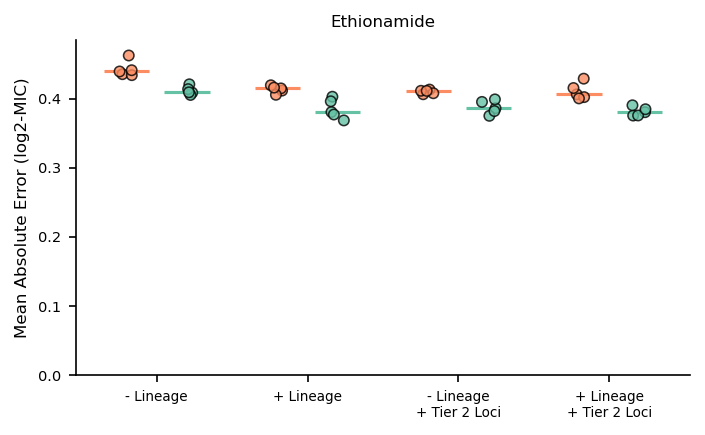

In [44]:
df_ETH_tier2, df_pvals = get_performance_comparison_CNN_Reg('ETH', model_order=None, plot_col='Binned_MAE', plot=True)

In [49]:
df_ETH_tier2.query("Num_Loci == 7 & Model=='CNN'")

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV,Addl_Data,Binned_MAE_exp,Binned_MSE_exp,Without_doubling
0,ETH,CNN,7,0.375391,0.713057,0.852288,1.302296,0.866947,0.667061,0.711004,0.649171,0.951124,0.729814,0.900093,0.800147,0,+ Lineage\n+ Tier 2 Loci,1.297191,1.639274,0.133053
1,ETH,CNN,7,0.380263,0.700011,0.844117,1.276261,0.881886,0.677221,0.712171,0.685083,0.930899,0.668464,0.889356,0.807991,1,+ Lineage\n+ Tier 2 Loci,1.301579,1.624518,0.118114
2,ETH,CNN,7,0.375522,0.690920,0.845728,1.263787,0.887021,0.672917,0.712719,0.632597,0.952247,0.729299,0.898226,0.792422,2,+ Lineage\n+ Tier 2 Loci,1.297309,1.614312,0.112979
3,ETH,CNN,7,0.390237,0.715373,0.858505,1.312087,0.879085,0.665290,0.704150,0.616022,0.950562,0.717042,0.894024,0.783292,3,+ Lineage\n+ Tier 2 Loci,1.310609,1.641907,0.120915
4,ETH,CNN,7,0.384520,0.717842,0.835668,1.293863,0.889823,0.676398,0.717695,0.629834,0.953933,0.735484,0.899160,0.791883,4,+ Lineage\n+ Tier 2 Loci,1.305426,1.644720,0.110177
0,ETH,CNN,7,0.386024,0.723460,0.856520,1.314160,0.877684,0.659035,0.696279,0.535912,0.964045,0.751938,0.891690,0.749978,0,- Lineage\n+ Tier 2 Loci,1.306787,1.651138,0.122316
1,ETH,CNN,7,0.395112,0.715847,0.850320,1.307287,0.873483,0.665580,0.699900,0.613260,0.947753,0.704762,0.891223,0.780506,1,- Lineage\n+ Tier 2 Loci,1.315045,1.642447,0.126517
2,ETH,CNN,7,0.374997,0.667963,0.854713,1.260780,0.885621,0.681136,0.711812,0.632597,0.951685,0.726984,0.897759,0.792141,2,- Lineage\n+ Tier 2 Loci,1.296837,1.588829,0.114379
3,ETH,CNN,7,0.381876,0.707476,0.852764,1.286886,0.882353,0.648409,0.702329,0.599448,0.950000,0.709150,0.890756,0.774724,3,- Lineage\n+ Tier 2 Loci,1.303035,1.632945,0.117647
4,ETH,CNN,7,0.398770,0.715406,0.830005,1.276913,0.877684,0.657715,0.707095,0.607735,0.952247,0.721311,0.894024,0.779991,4,- Lineage\n+ Tier 2 Loci,1.318384,1.641945,0.122316


# CNN Performance Comparisons +/- Lineage

In [71]:
df_pvals_lineage_comparison = []

for drug in os.listdir(data_dir):
    try:
        df_pvals_lineage_comparison.append(get_performance_comparison_lineage(drug, regression=False))
    except:
        print(f"{drug} not finished")

df_pvals_lineage_comparison = pd.concat(df_pvals_lineage_comparison)

In [72]:
df_pvals_lineage_comparison.query("Lineage_Better_pval <= 0.05 | Lineage_Worse_pval <= 0.05")

,Variable,Lineage_Better_pval,Lineage_Worse_pval,Drug
0,Binned_MAE,0.003968,1.0,ETH
0,Binned_MAE,0.003968,1.0,MXF
0,Binned_MAE,0.972222,0.047619,PZA


# CRyPTIC Essential Agreements (for comparing to Lachapelle et al., 2021)

In [29]:
def compute_cryptic_EA(drug, path, thresh):

    test_pred = pd.read_csv(os.path.join(results_dir, path, "test_predictions.csv"))
    df_phenos = pd.read_csv(os.path.join(data_dir, drug, "data_for_model.csv"))
    
    test_pred_cryptic = test_pred.loc[test_pred["Isolate"].isin(df_phenos.query("DB_OF_ORIGIN=='CRyPTIC'").ROLLINGDB_ID.values)]
    assert len(test_pred_cryptic) > 0

    # round so that i.e. 0.059999 is included in essential agreement for an isolate with MIC = (0.12, 0.25]
    test_pred_cryptic["y_pred_exp"] = np.round(np.exp2(test_pred_cryptic["y_pred"]), 2)
    
    test_pred_cryptic_R = test_pred_cryptic.query("upper > @thresh")
    test_pred_cryptic_S = test_pred_cryptic.query("upper <= @thresh")

    print(f"{drug}: {len(test_pred_cryptic.query('lower / 2 <= y_pred_exp & y_pred_exp <= upper * 2')) / len(test_pred_cryptic)}")
    # print(f"CRyPTIC-R: {len(test_pred_cryptic_R.query('lower / 2 <= y_pred_exp & y_pred_exp <= upper * 2')) / len(test_pred_cryptic_R)}")
    # print(f"CRyPTIC-S: {len(test_pred_cryptic_S.query('lower / 2 <= y_pred_exp & y_pred_exp <= upper * 2')) / len(test_pred_cryptic_S)}")

In [30]:
for drug in os.listdir(data_dir):

    if drug in ['MXF', 'BDQ']:
        model_path = f"{drug}_lineage_amino_acid"
    else:
        model_path = f"{drug}_amino_acid"

    try:
        compute_cryptic_EA(drug, model_path, cc_dict[drug])
    except:
        pass

BDQ: 0.94049008168028
DLM: 0.7827669902912622
EMB: 0.9301423027166882
INH: 0.9095744680851063
LEV: 0.922882427307206
LZD: 0.898921832884097
MXF: 0.8998527245949927
RIF: 0.9715909090909091


# Loss Curves

Plot validation loss for the 10 replicates and the actual model on top. 

In [73]:
def plot_histories(path, patience_epochs=200, cv=True, saveName=None):

    if cv:
        combined_replicates = [pd.read_csv(fName)[['val_loss']] for fName in glob.glob(os.path.join(path, f"cross_validation/history*.csv"))]
    
    history = pd.read_csv(os.path.join(path, "history.csv"))
    history = history.iloc[:-patience_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    if cv:
        for i, single_rep in enumerate(combined_replicates):
            #single_rep = single_rep.iloc[:-patience_epochs, :]
            print(f"Trained replicate {i} for {len(single_rep)-patience_epochs} epochs")
            
            plt.plot(single_rep.index.values + 1, single_rep['val_loss'], color="lightgray")

    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)
    print(f"Trained full model for {len(history)} epochs")

    plt.xlabel("Epoch", fontsize=12)
    plot_title = "Validation Loss" + " for " + os.path.basename(path) + " Model"
    plt.title(plot_title, fontsize=14)
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName, dpi=300)

Trained replicate 0 for 233 epochs
Trained replicate 1 for 12 epochs
Trained replicate 2 for 90 epochs
Trained replicate 3 for 66 epochs
Trained replicate 4 for 10 epochs
Trained full model for 253 epochs


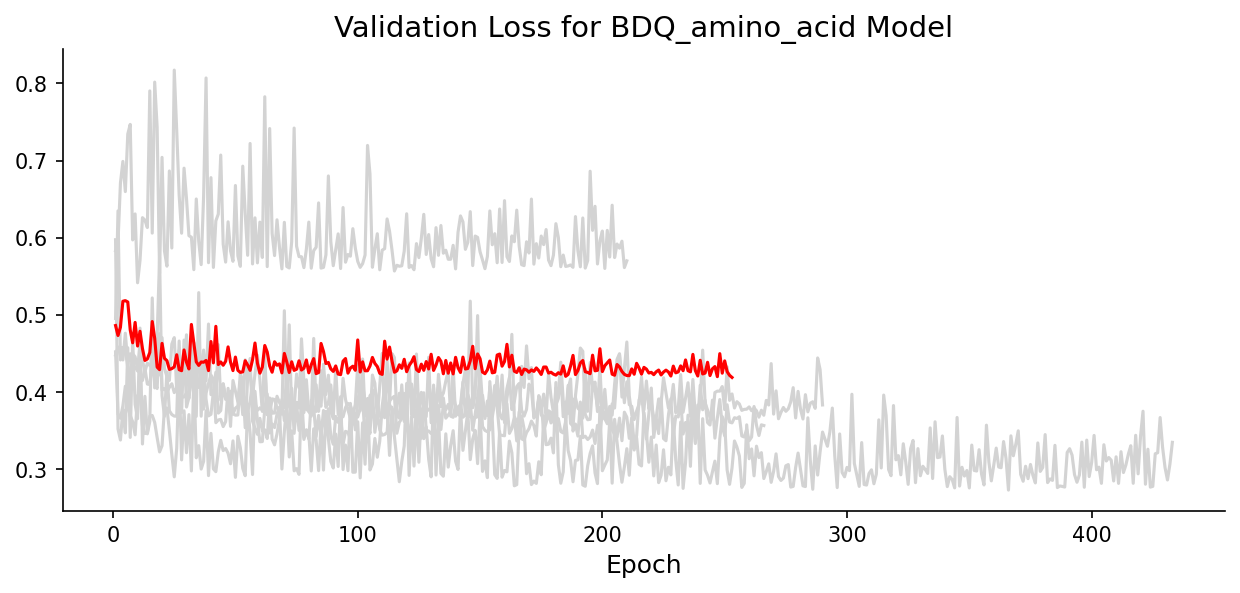

In [74]:
plot_histories(os.path.join(results_dir, 'BDQ_amino_acid'), patience_epochs=200, cv=True)

Trained replicate 0 for 231 epochs
Trained replicate 1 for 2 epochs
Trained replicate 2 for 42 epochs
Trained replicate 3 for 59 epochs
Trained replicate 4 for 8 epochs
Trained full model for 385 epochs


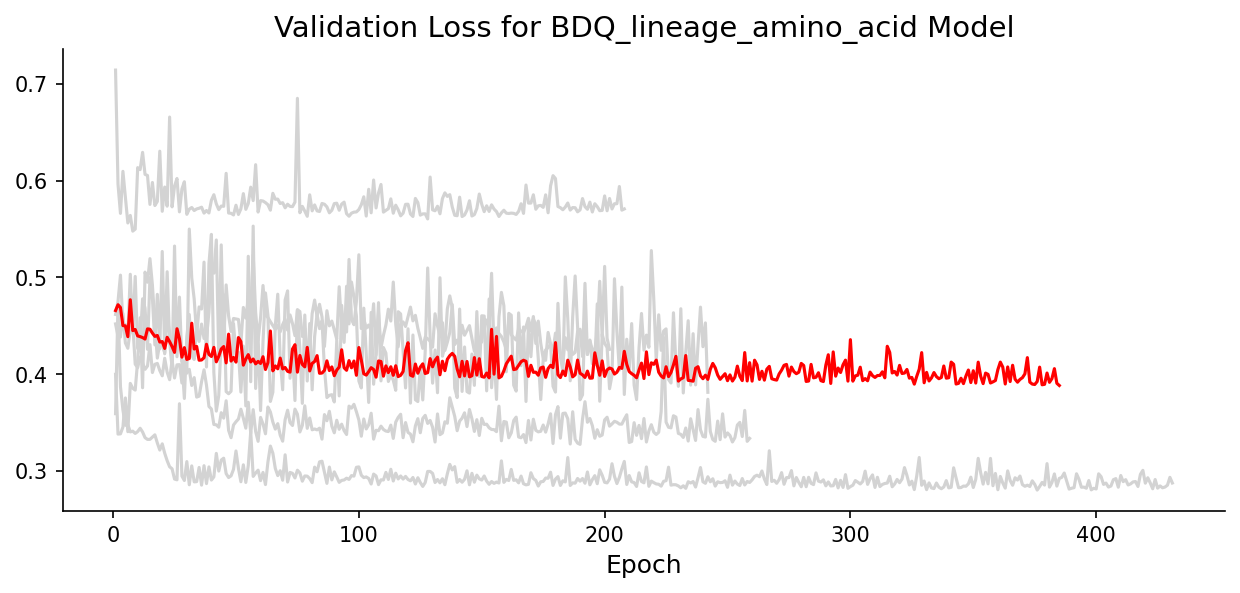

In [75]:
plot_histories(os.path.join(results_dir, "BDQ_lineage_amino_acid"), patience_epochs=200, cv=True)

In [101]:
# plot_histories(os.path.join(results_dir, "PZA_peptide_amino_acid"), binary=False, patience_epochs=150, replicates=True)

In [102]:
# plot_histories(os.path.join(results_dir, "PZA_peptide"), binary=False, patience_epochs=150, replicates=True)

# Binary Statistics: Compare with 2023 WHO Catalog

## Predicted R if any 1) Assoc w R or 2) Assoc w R - Interim mutation is present

In [50]:
def compute_t_dist_confidence_interval(cv_results_df, alpha=0.05):

    metrics_lst = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Balanced_Acc']
    
    # keep only the metrics of interest
    df_cv_metrics = pd.DataFrame(cv_results_df[metrics_lst].mean()).reset_index()

    # the mean is the test value
    df_cv_metrics.columns = ['Metric', 'Test']

    # compute standard deviation and standard error = SD / sqrt(n)
    df_std = pd.DataFrame(cv_results_df[metrics_lst].std()).reset_index()
    df_std.columns = ['Metric', 'SD']
    df_std['STD_error'] = df_std['SD'] / np.sqrt(len(cv_results_df))

    # get the critical value. Because there are 5 CV splits, and this is < 30, use the t distribution, not the standard normal
    confidence = 1 - alpha
    t_value = st.t.ppf((1 + confidence) / 2., len(cv_results_df) - 1)

    df_cv_metrics = df_cv_metrics.merge(df_std)
    df_cv_metrics['Low'] = df_cv_metrics['Test'] - t_value * df_cv_metrics['STD_error']
    df_cv_metrics['High'] = df_cv_metrics['Test'] + t_value * df_cv_metrics['STD_error']

    return df_cv_metrics[['Metric', 'Test', 'Low', 'High']]
    
    
    
def compute_exact_confidence_intervals_binary_stats(pred_df, cc, binarize=False, alpha=0.05):

    if binarize:
        pred_df['y_pred'] = (np.exp2(pred_df['y_pred']) > cc).astype(int)
        pred_df['y_test'] = (pred_df['upper'] > cc).astype(int)

    tp = len(pred_df.query("y_pred==1 & y_test==1"))
    tn = len(pred_df.query("y_pred==0 & y_test==0"))
    fn = len(pred_df.query("y_pred==0 & y_test==1"))
    fp = len(pred_df.query("y_pred==1 & y_test==0"))
    
    assert tp + tn + fn + fp == len(pred_df)

    # possible that tp + fp = 0 (meaning nothing was predicted resistant), so make ppv 0 if so, otherwsie get a divide by 0 error for ppv
    if tp + fp == 0:
        ppv = 0
    else:
        ppv = tp / (tp + fp)

    metrics_df = pd.DataFrame({'Metric': ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Balanced_Acc'],#, 'F1'],
                               'Test': [tp / (tp + fn), # sensitivity
                                       tn / (tn + fp), # specificity
                                       ppv, # precision (ppv)
                                       (tp + tn) / (tp + tn + fp + fn), # accuracy
                                       0.5 * (tp / (tp + fn) + tn / (tn + fp)), # balanced accuracy
                                       # tp / (tp + 0.5*(fp + fn))], # F1 score
                                       ]
                             }).set_index('Metric')

    # sensitivity
    ci = st.binomtest(k=tp, n=tp + fn, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Sensitivity', ['Low', 'High']] = [ci.low, ci.high]
    
    # specificity
    ci = st.binomtest(k=tn, n=tn + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Specificity', ['Low', 'High']] = [ci.low, ci.high]
    
    # precision (ppv)
    if tp + fp == 0:
        metrics_df.loc['Precision', ['Low', 'High']] = [0, 0]
    else:
        ci = st.binomtest(k=tp, n=tp + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
        metrics_df.loc['Precision', ['Low', 'High']] = [ci.low, ci.high]
    
    # accuracy
    ci = st.binomtest(k=tp + tn, n=tp + tn + fn + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Accuracy', ['Low', 'High']] = [ci.low, ci.high]
    
    # balanced accuracy
    ci = st.binomtest(k=tp*tn + tp*fp + tn*tp + tn*fn, n=2 * (tp + fn) * (tn + fp), p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Balanced_Acc', ['Low', 'High']] = [ci.low, ci.high]
    
    # # F1 score
    # ci = st.binomtest(k=tp, n=int(tp + 0.5*(fp + fn)), p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    # metrics_df.loc['F1', ['Low', 'High']] = [ci.low, ci.high]
    
    assert sum(metrics_df['Test'] < metrics_df['Low']) == 0
    assert sum(metrics_df['Test'] > metrics_df['High']) == 0

    return metrics_df.reset_index()
    
    
    
def single_drug_binary_results(model_path, cc, V1=False, alpha=0.05):

    drug = model_path.split('_')[0]

    catalog_fName = os.path.join(results_dir, drug, "catalog_test_predictions_V2.csv")

    if V1:
        catalog_fName = catalog_fName.replace('V2', 'V1')

    # if AF_thresh != 0.75:
    #     catalog_fName = '.'.join(catalog_fName.split(".")[:-1]) + f"_AF_thresh_{int(AF_thresh*100)}." + catalog_fName.split(".")[-1]
    #     cnn_fName = os.path.join(results_dir, model_path, f"test_predictions_AF_thresh_{int(AF_thresh*100)}.csv")
    #     reg_fName = os.path.join(results_dir, model_path, f"ridge/test_predictions_AF_thresh_{int(AF_thresh*100)}.csv")
    # else:
    cnn_fName = os.path.join(results_dir, model_path, "results.csv")
    reg_fName = os.path.join(results_dir, model_path, "ridge", "results.csv")
    
    catalog_predictions = pd.read_csv(catalog_fName)
    cnn_predictions = pd.read_csv(os.path.join(results_dir, model_path, "test_predictions.csv"))
    reg_predictions = pd.read_csv(os.path.join(results_dir, model_path, "ridge", "test_predictions.csv"))

    catalog_metrics_df = compute_exact_confidence_intervals_binary_stats(catalog_predictions, cc, alpha=alpha)
    cnn_metrics_df = compute_exact_confidence_intervals_binary_stats(cnn_predictions, cc, binarize=True, alpha=alpha)
    reg_metrics_df = compute_exact_confidence_intervals_binary_stats(reg_predictions, cc, binarize=True, alpha=alpha)
    
    # cnn_results = pd.read_csv(cnn_fName)
    # reg_results = pd.read_csv(reg_fName)
    # cnn_metrics_df = compute_t_dist_confidence_interval(cnn_results, alpha=alpha)
    # reg_metrics_df = compute_t_dist_confidence_interval(reg_results, alpha=alpha)

    catalog_metrics_df['Model'] = 'Catalog'
    cnn_metrics_df['Model'] = 'CNN'
    reg_metrics_df['Model'] = 'Regression'

    return pd.concat([catalog_metrics_df, cnn_metrics_df, reg_metrics_df], axis=0)



def plot_single_drug_all_metrics(model_path, cc, save=False, V1=False):

    metrics_lst = ['Sensitivity', 'Specificity', 'Precision']#, 'F1']
    
    drug = model_path.split("_")[0]

    # get binary metrics and exact confidence intervals
    df_metrics = single_drug_binary_results(model_path, cc, V1=V1)

    categories = ['Catalog', 'Regression', 'CNN']
    df_metrics = df_metrics.set_index(["Model", "Metric"])
    
    palette=dict(zip(["CNN", "Regression", "Catalog"], sns.color_palette("Set2").as_hex()))

    # Bar width and positions
    bar_width = 0.05
    # bar_positions = np.arange(len(categories))
    
    errwidth = 0.04
    errlinewidth = 0.5
    
    fig, axs = plt.subplots(1, len(metrics_lst), figsize=(len(metrics_lst)*2, 3), sharex=True, sharey=True)
    axs = axs.flatten()

    for i, metric in enumerate(metrics_lst):

        ax = axs[i]
        
        # Plot bars for each category
        for j, category in enumerate(categories):
        
            # plot_df.loc['Catalog', 'Sensitivity']['Test']
            
            test = df_metrics.loc[category, metric]["Test"] * 100
            lower = df_metrics.loc[category, metric]["Low"] * 100
            upper = df_metrics.loc[category, metric]["High"] * 100
            
            # Plot the test value as a bar
            patch = ax.bar(j, test, color=palette[category], label=category, linewidth=0.5, edgecolor='black')
            ax.bar_label(patch, label_type='center', fmt='%.1f', fontsize=9)
            
            # Plot the confidence interval as a vertical line
            ax.vlines(j, lower, upper, color='black', linewidth=errlinewidth)
        
            # plot horizontal lines to make the error bars look nicer
            ax.hlines(lower, j - errwidth, j + errwidth, color='black', linewidth=errlinewidth)
            ax.hlines(upper, j - errwidth, j + errwidth, color='black', linewidth=errlinewidth)
        
        ax.set_title(metric, fontsize=10)
        
        # remove x-axis ticks and labels
        ax.set_xticks([])
        ax.set_xticklabels([])
    
    # Show the plot
    plt.ylim(0, 100)
    plt.suptitle(f"{abbr_drug_dict[drug]}\n\n", y=1.02)
    plt.legend(bbox_to_anchor=(0.2, -0.15), loc="lower right", ncol=len(categories), fontsize=8)
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(f"results/{abbr_drug_dict[drug]}/binary_metrics_comparison.svg", bbox_inches='tight')
        plt.close()
    else:
        plt.show()

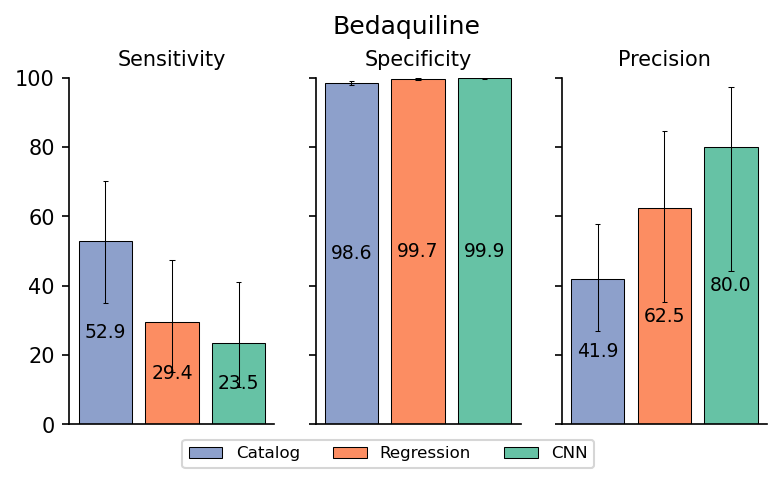

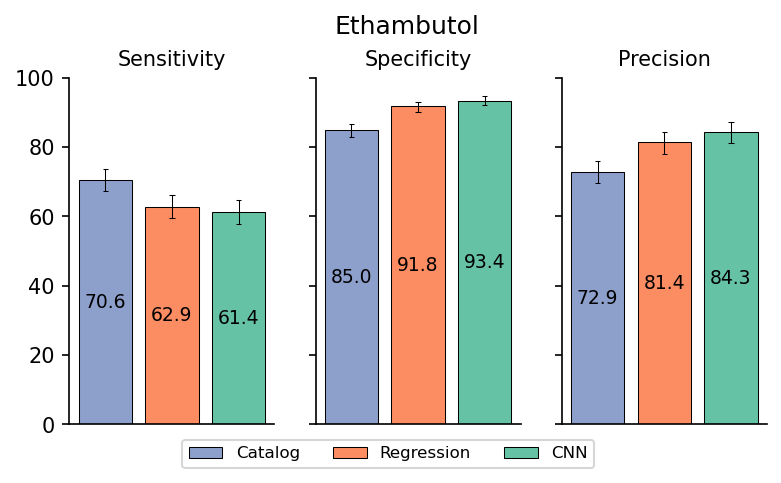

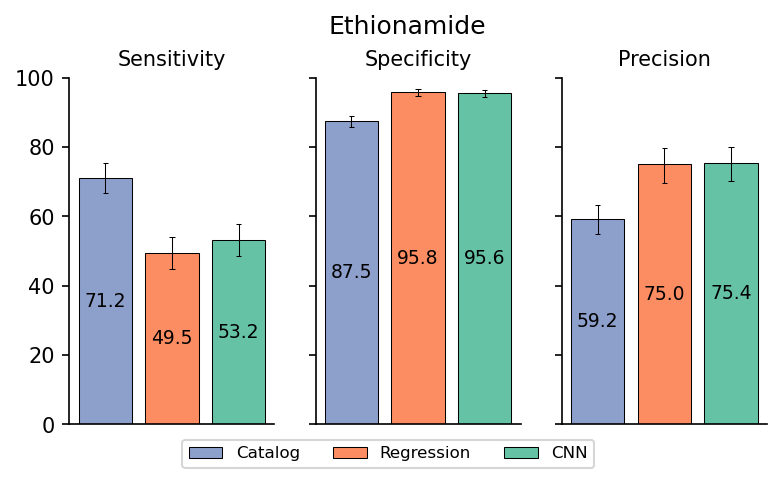

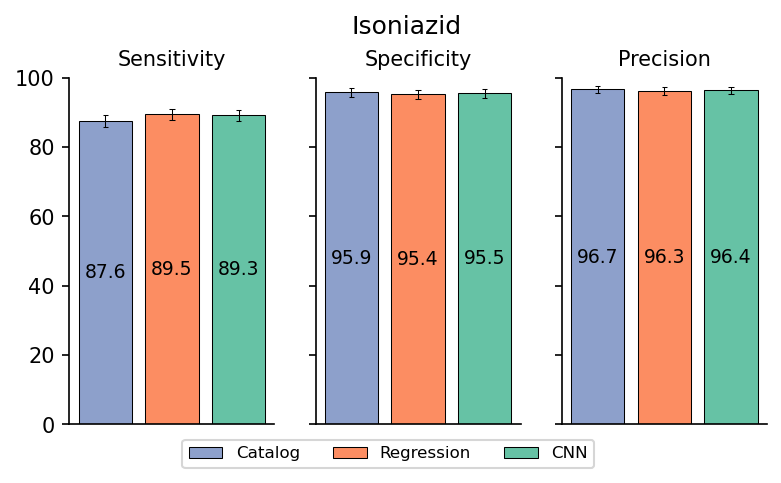

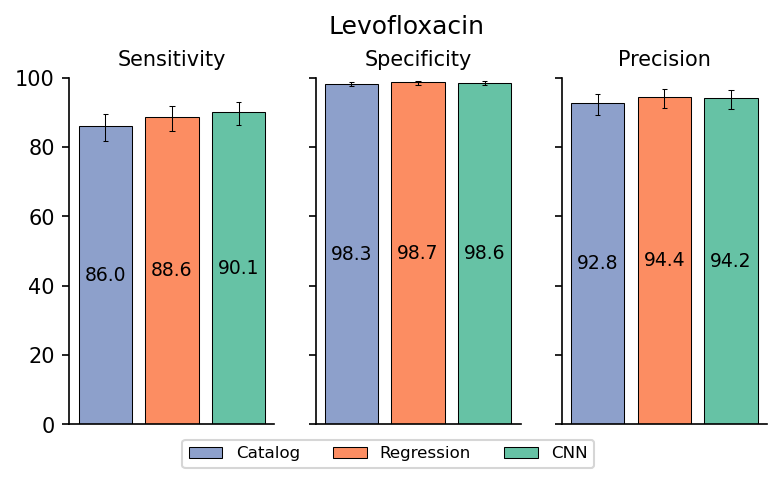

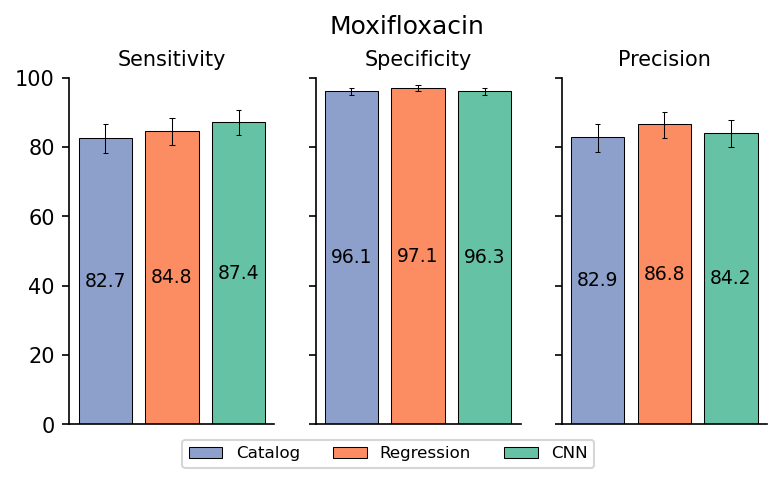

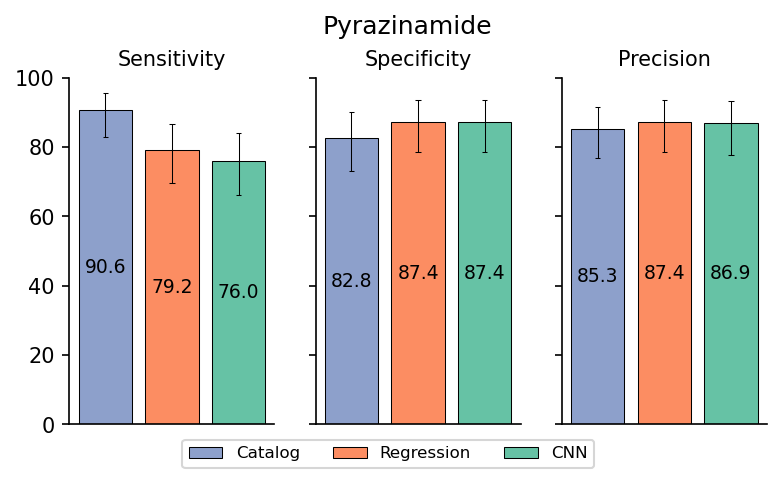

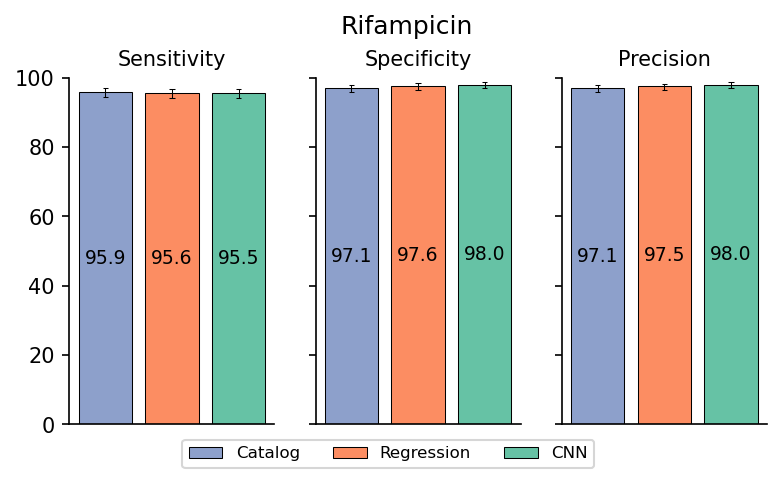

In [51]:
V1 = False

for drug in np.sort(os.listdir(data_dir)):

    try:
        # if drug not in ['MXF', 'BDQ', 'CFZ', 'ETH', 'DLM']:
        #     plot_single_drug_all_metrics(f"{drug}_lineage_amino_acid", cc_dict[drug], V1=V1, lowAF=lowAF)
        # else:
        if drug == 'PZA':
            model_path = f"{drug}_amino_acid"
        else:
            model_path = f"{drug}_lineage_amino_acid"
            
        plot_single_drug_all_metrics(model_path, cc_dict[drug], V1=V1)
    except:
        print(f"{drug} not finished")

In [153]:
def compare_model_stats(df_results, var, drugs_lst, model_1, model_2):
    
    for drug in drugs_lst:
        
        _, pval = st.mannwhitneyu(df_results.query("Drug==@drug & Model==@model_1")[var],
                                  df_results.query("Drug==@drug & Model==@model_2")[var],
                                  alternative='two-sided'
                                 )
    
        if pval < 0.05:
    
            _, pval = st.mannwhitneyu(df_results.query("Drug==@drug & Model==@model_1")[var],
                                      df_results.query("Drug==@drug & Model==@model_2")[var],
                                      alternative='greater'
                                     )
    
            if pval < 0.05:
                final_str = "Greater"
                final_pval = pval
            else:
                _, pval = st.mannwhitneyu(df_results.query("Drug==@drug & Model==@model_1")[var],
                                          df_results.query("Drug==@drug & Model==@model_2")[var],
                                          alternative='less'
                                         )    
                if pval < 0.05:
                    final_str = "Less"
                    final_pval = pval
                else:
                    final_str = "IDK"
                    finale_pval = pval
        else:
            final_str = "Same"
    
        print(drug, final_str, pval)
    print("\n")

In [154]:
# var = "Sensitivity"
# compare_model_stats(sensitivity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Catalog")
# # compare_model_stats(df_binary_results, var, ['RIF', 'PZA', 'LEV', 'MXF'], "Regression", "Catalog")
# compare_model_stats(sensitivity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Regression")

In [155]:
# var = "Specificity"
# compare_model_stats(specificity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Catalog")
# # compare_model_stats(df_binary_results, var, ['RIF', 'PZA', 'LEV', 'MXF'], "Regression", "Catalog")
# compare_model_stats(specificity_metrics, var, ['RIF', 'PZA', 'LEV', 'MXF'], "CNN", "Regression")

# Which Isolates Were Missed by Catalog or Models for PZA, MXF, and LEV?

In [5]:
drug = "MXF"
model_path = "MXF_gyrBA_peptide_lineage"
cc = 0.5

df_model = pd.read_csv(os.path.join(data_path, drug, "data_for_model.csv"))
isolate_variants_df = pd.read_csv(os.path.join(data_path, drug, "isolate_variants_fixed_annot.csv"))

CNN_pred = pd.read_csv(os.path.join(results_dir, model_path, "test_predictions.csv")).rename(columns={'y_pred': 'y_pred_log2_MIC'})
CNN_pred['y_pred'] = (CNN_pred['y_pred_log2_MIC'] > np.log2(cc)).astype(int)

catalog_pred = pd.read_csv(os.path.join(results_dir, model_path.replace("_lineage", "").replace("_peptide", ""), "catalog_test_predictions_lowAF.csv"), usecols=['Isolate', 'y_pred']).rename(columns={'y_pred': 'y_pred_catalog'})
CNN_pred = CNN_pred.merge(catalog_pred)

In [ ]:
minor_alleles = pd.read_pickle("/home/sak0914/who-analysis/PCA/minor_allele_counts.pkl.gz", compression='gzip')

In [ ]:
minor_alleles.shape

In [3]:
# TP / TP + FN. So look for missed true positives and false negatives

# what did the catalog get that the CNN missed?
search_isolates = CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False).Isolate.values
print(len(search_isolates))
CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False)

4


,Isolate,y_test,lower,upper,y_pred_log2_MIC,compute_error,y_pred,y_pred_catalog
463,ERR4797524,1.000000,2.0,inf,-1.151815,1,0,1
519,ERR4812196,1.000000,2.0,inf,-1.690425,1,0,1
829,ERR2510847,1.000000,2.0,inf,-2.794118,1,0,1
936,ERR4831432,-0.415037,0.5,1.0,-1.236186,1,0,1


In [48]:
who_variants = pd.read_csv("")
who_variants.rename(columns={'drug': 'drug_abbr'}, inplace=True)

In [28]:
coll_2014.loc[coll_2014['#lineage']=='lineage3']

,#lineage,position,allele_change,tag
15,lineage3,3273107,C/A,coll2014


In [24]:
isolate_variants_df.query("Isolate in ['ERR4812196', 'ERR2510847']")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
2162,6620,G,A,Amb,0.27,gyrB,missense_variant,c.1381G>A,p.Asp461Asn,ERR2510847,gyrB_p.Asp461Asn
2163,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,ERR2510847,gyrA_p.Glu21Gln
2164,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,ERR2510847,gyrA_p.Ser95Thr
2165,9304,G,A,PASS,1.0,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,ERR2510847,gyrA_p.Gly668Asp
2166,9841,C,T,PASS,0.99,gyrA-Rv0007,intergenic_region,n.9841C>T,.,ERR2510847,gyrA-Rv0007_.
13023,7362,G,C,PASS,1.0,gyrA,missense_variant,c.61G>C,p.Glu21Gln,ERR4812196,gyrA_p.Glu21Gln
13024,7563,G,T,Amb,0.67,gyrA,missense_variant,c.262G>T,p.Gly88Cys,ERR4812196,gyrA_p.Gly88Cys
13025,7585,G,C,PASS,1.0,gyrA,missense_variant,c.284G>C,p.Ser95Thr,ERR4812196,gyrA_p.Ser95Thr
13026,8040,G,A,PASS,1.0,gyrA,missense_variant,c.739G>A,p.Gly247Ser,ERR4812196,gyrA_p.Gly247Ser
13027,9304,G,A,PASS,1.0,gyrA,missense_variant,c.2003G>A,p.Gly668Asp,ERR4812196,gyrA_p.Gly668Asp


In [26]:
df_model.query("ROLLINGDB_ID in @search_isolates")[['ROLLINGDB_ID', 'MXF_lower_bound', 'MXF_upper_bound', 'Coll2014', 'Lineage']]

,ROLLINGDB_ID,MXF_lower_bound,MXF_upper_bound,Coll2014,Lineage
2276,ERR4797524,2.0,inf,3,3
2570,ERR4812196,2.0,inf,4.3.3,4
4007,ERR2510847,2.0,inf,4.2.1,4
4528,ERR4831432,0.5,1.0,3,3


In [17]:
isolates_with_var = isolate_variants_df.query("mutation=='gyrA_p.Asp94Ala' & FILTER=='PASS'").Isolate.values

In [19]:
df_model.query("ROLLINGDB_ID in @isolates_with_var")['MXF_midpoint'].mean()

1.475

In [22]:
df_model.query("ROLLINGDB_ID in @isolates_with_var")['MXF_upper_bound'].value_counts()

MXF_upper_bound
1.0    26
inf    26
0.5    18
2.0    15
8.0     2
4.0     2
6.0     1
Name: count, dtype: int64

In [23]:
df_model.query("ROLLINGDB_ID in @isolates_with_var & MXF_upper_bound==0.5")

,ROLLINGDB_ID,BIOSAMPLE_ACCESSION,ID,ISOLATION_LOCATION,DB_OF_ORIGIN,STUDY_NAME,STUDY_PMID,TESTING_LOCATION,MEDIA,MXF,MXF_lower_bound,MXF_midpoint,MXF_upper_bound,MXF_quality,Path,Coll2014,Binary,Lineage,category
321,ERR4810558,ERS5298585,site.02.subj.0468.lab.234005-14.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
874,ERR4830975,ERS5320048,site.03.subj.DR-191.lab.IML-01141.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set
895,ERR4831022,ERS5320095,site.03.subj.DR-258.lab.IML-01194.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
915,ERR4830912,ERS5319985,site.03.subj.DR-47.lab.IML-01078.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set
1275,ERR4822377,ERS5312441,site.03.subj.KGZ-3244-2018.lab.3244-2018.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
1432,ERR4796423,ERS5281354,site.04.subj.00009.lab.633291.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_test_set
1636,ERR4796633,ERS5281564,site.04.subj.00327.lab.703443.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
1930,ERR4796896,ERS5281912,site.04.subj.00825.lab.708226.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,4.8,0,4,original_test_set
2180,ERR4797426,ERS5282450,site.04.subj.01204.lab.720549.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,MEDIUM,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set
2334,ERR4797668,ERS5282694,site.04.subj.01454.lab.727351.iso.1,NaN,CRyPTIC,The CRyPTIC Consortium,https://doi.org/10.1101/2021.09.14.460274(pre-...,Not specified in paper,m7h10,0.5,0.25,0.375,0.5,HIGH,/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/VCF/...,2.2.1,0,2,original_train_set


In [9]:
np.exp2(-1.151815), np.exp2(-1.236186)

(0.45005867322322307, 0.424493391725395)

In [4]:
len(CNN_pred), len(CNN_pred.query("y_pred != y_pred_catalog"))

(1471, 16)

In [ ]:
# TP / TP + FN. So look for missed true positives and false negatives

# what did the catalog get that the CNN missed?
search_isolates = CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False).Isolate.values
print(len(search_isolates))
CNN_pred.query("y_pred==0 & y_pred_catalog==1 & upper > @cc").sort_values("upper", ascending=False)

In [188]:
isolate_variants_df.query("Isolate in @search_isolates")

,POS,REF,ALT,FILTER,AF,GENE,EFFECT,NUC,PROT,Isolate,mutation
